 Установка питона

In [ ]:
%cd /content

#  Python 3.9
!wget -q https://github.com/indygreg/python-build-standalone/releases/download/20250612/cpython-3.9.23+20250612-x86_64-unknown-linux-gnu-install_only_stripped.tar.gz -O python39.tar.gz

!rm -rf /content/python39 /content/gan_env
!mkdir -p /content/python39
!tar -xzf python39.tar.gz -C /content/python39 --strip-components=1

!/content/python39/bin/python3.9 --version

# Создаём venv
!/content/python39/bin/python3.9 -m venv /content/gan_env

# Обновляем pip
!/content/gan_env/bin/python -m pip install --upgrade pip setuptools wheel

%cd /content/drive/MyDrive/GAN_project

# Ставим зависимости проекта
!/content/gan_env/bin/pip install -r requirements.txt

/content
Python 3.9.23
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 62.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 15.3 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 58.1.0
    Uninstalling setuptools-58.1.0:
      Successfully uninstalled setuptools-58.1.0
  Attempting uninstall: pip
    Found existing installation: pip 23.0.1
    Uninstalling pip-23.0.1:
      Successfully uninstalled pip-23.0.1
/content/drive/MyDrive/GAN_project
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 128.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
#Подключение диска с проектом
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys

project_path = '/content/drive/MyDrive/GAN_project'
sys.path.insert(0, project_path)
os.chdir(project_path)

In [ ]:
# Если требуется распаковка данных
!cd /content/drive/MyDrive/GAN_project/data && unzip fhcal_data3.zip

Archive:  fhcal_data3.zip
  inflating: fhcal_data3.npz         


In [ ]:
import torch
from pipeline.data import get_physics_dataset, UnifiedDatasetWrapper


def form_dataset(train: bool = False) -> torch.utils.data.Dataset:
    data_filepath = project_path + '/data/fhcal_data3.npz'
    return UnifiedDatasetWrapper(get_physics_dataset(data_filepath, train=train))

In [ ]:
train_dataset = form_dataset(True)

In [ ]:
import numpy as np

data = np.load('/content/drive/MyDrive/GAN_project/data/fhcal_data3.npz')

print(data.files)

for key in data.files:
    print(key, data[key].shape)

['EnergyDeposit', 'TotalEnergySci', 'ParticlePoint', 'ParticleMomentum', 'ParticlePDG']
EnergyDeposit (20067, 7, 5, 7)
TotalEnergySci (20067,)
ParticlePoint (20067, 3)
ParticleMomentum (20067, 3)
ParticlePDG (20067,)


In [ ]:
#Статистика по всему датасету
import numpy as np
total_energies = []
for i in range(min(1000, len(train_dataset))):
    total_energies.append(torch.sum(train_dataset[i][0]).item())

total_energies = np.array(total_energies)
print(f"Статистика по первым 1000 событиям:")
print(f"  Ненулевых: {np.sum(total_energies > 0)}")
print(f"  Среднее: {np.mean(total_energies):.6f}")
print(f"  Максимум: {np.max(total_energies):.6f}")

Статистика по первым 1000 событиям:
  Ненулевых: 1000
  Среднее: 2.070562
  Максимум: 9.144155


In [ ]:
# Проверка размеров
train_dataset[0][0].shape

torch.Size([7, 7, 5])

In [ ]:
from visualization_aux.visualize_physics import plot_fhcal_simple

def show_real_events_simple(dataset, indices):
    for idx in indices:
        single_event = dataset[idx][0]
        print(f"REAL event {idx}, total energy = {single_event.sum().item():.4f}")
        plot_fhcal_simple(single_event, event_idx=idx)

REAL event 0, total energy = 4.6686


/content/drive/MyDrive/GAN_project/visualization_aux/visualize_physics.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


REAL event 1, total energy = 4.1508
REAL event 2, total energy = 0.5818
REAL event 3, total energy = 1.5188
REAL event 4, total energy = 2.7617
REAL event 6, total energy = 1.0562


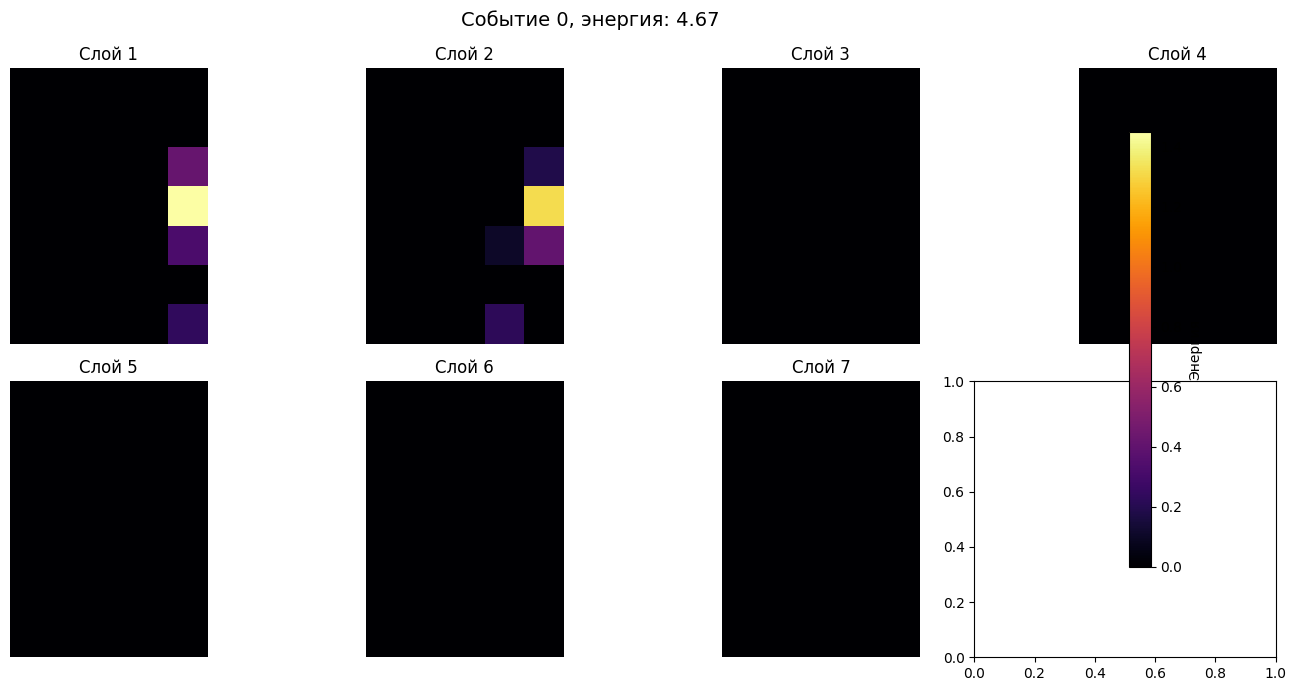

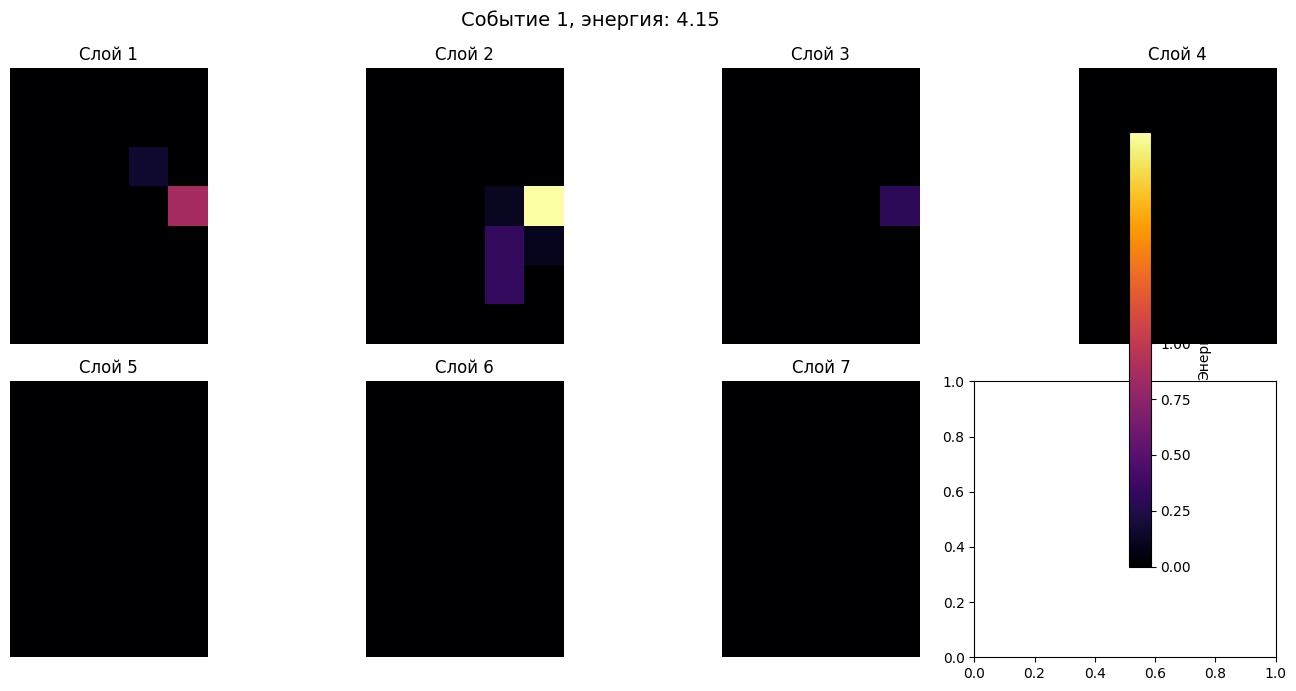

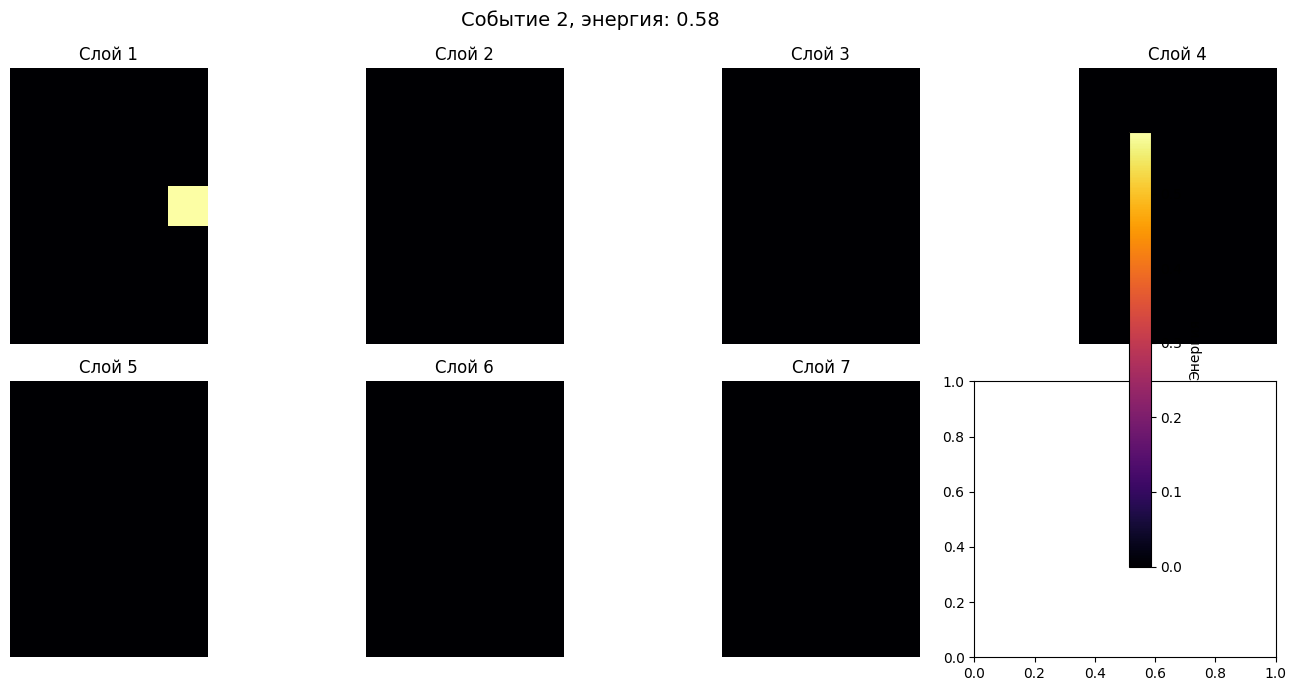

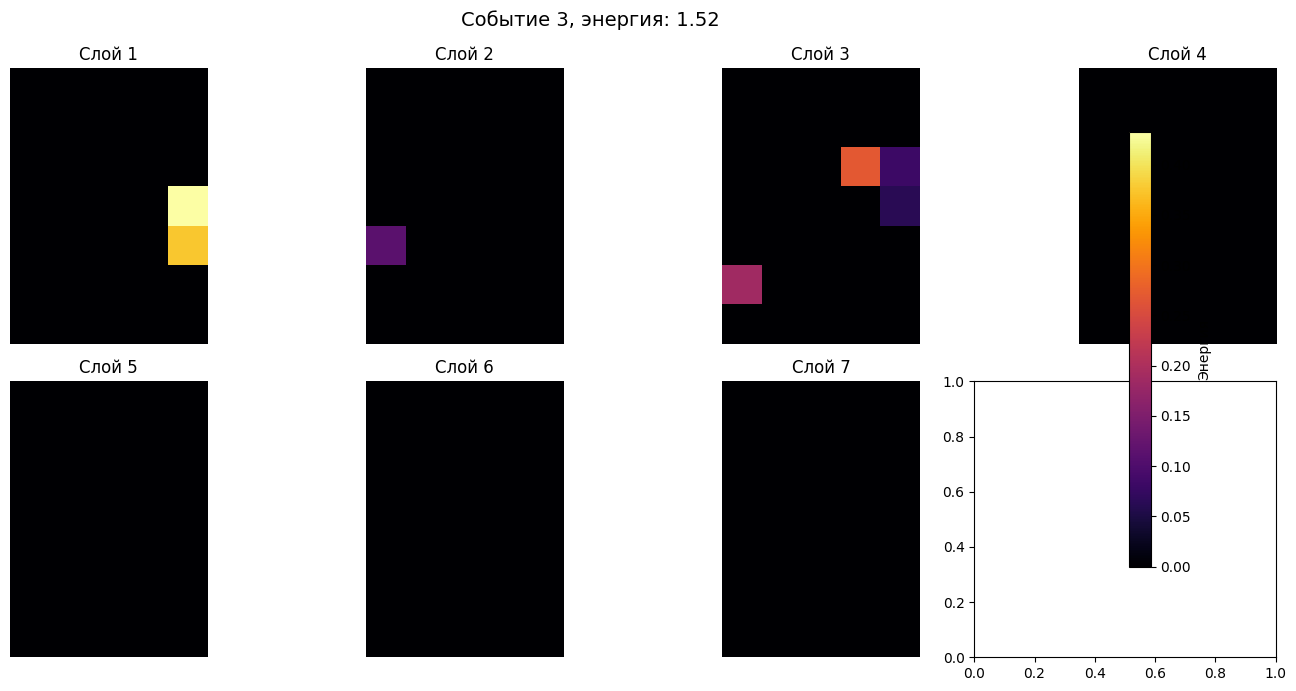

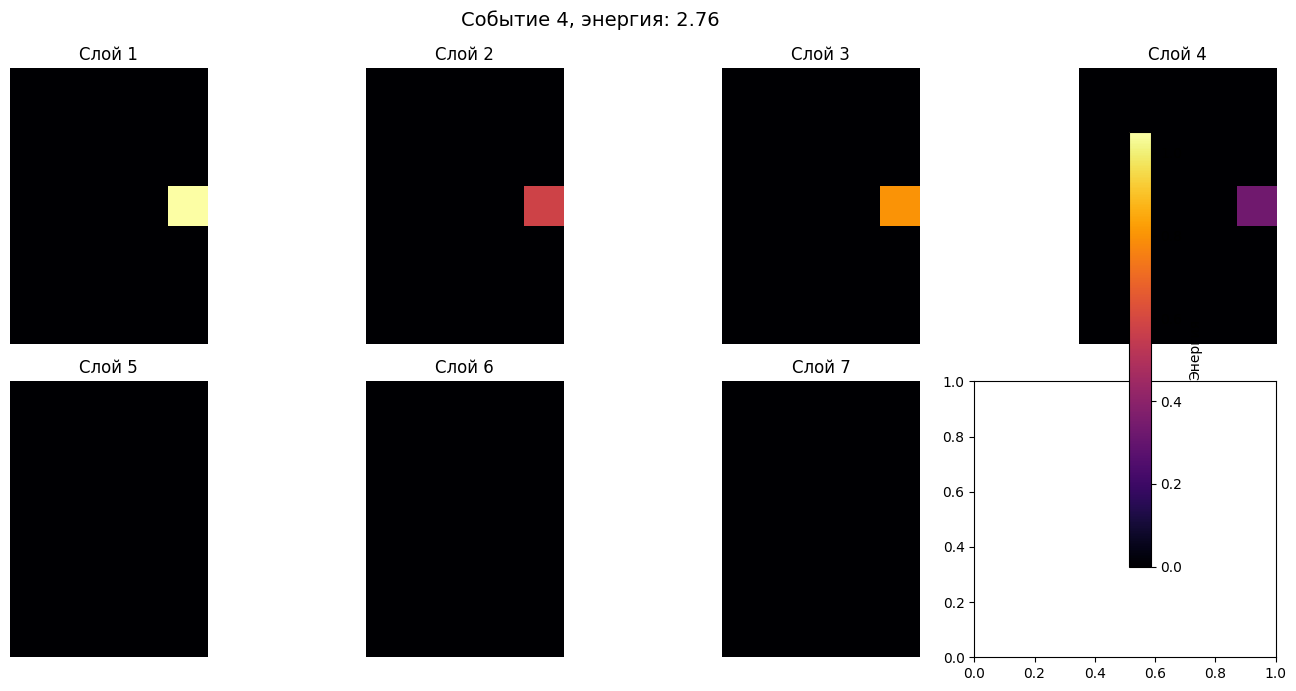

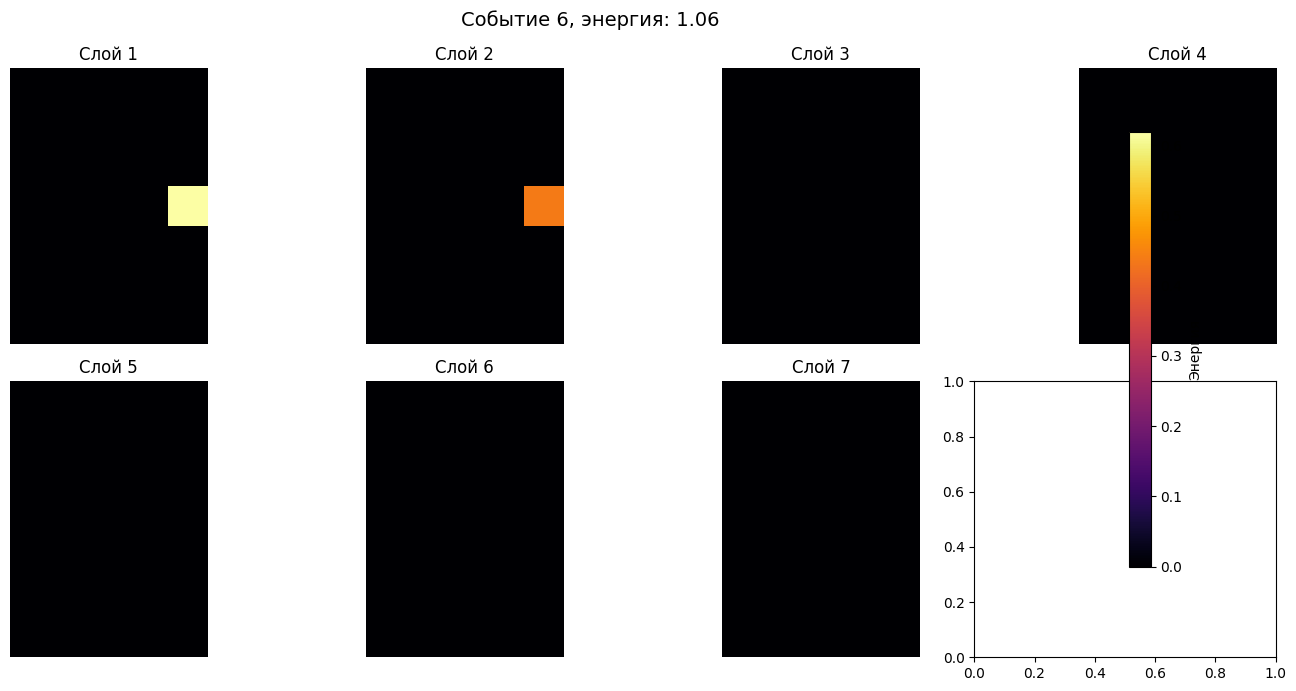

In [ ]:
show_real_events_simple(train_dataset, indices=[0, 1, 2, 3, 4, 6])

In [ ]:
from matplotlib import pyplot as plt
from visualization_aux.visualize_physics import energy_imshow


def show_one_energy_event_row(dataset, idx=0, layer=1, figsize=(15, 4)):
    single_event = dataset[idx][0]

    print(f"Event index: {idx}")
    print(f"shape: {tuple(single_event.shape)}")
    print(f"total energy: {single_event.sum().item():.4f}")

    fig, axs = plt.subplots(1, 3, figsize=figsize)

    axs[0].set_title(f"Layer {layer}, no log")
    energy_imshow(single_event, ax=axs[0], log_transform=False, layer=layer)

    axs[1].set_title(f"Layer {layer}, log1p")
    energy_imshow(single_event, ax=axs[1], log_transform=True, layer=layer)

    axs[2].set_title("All layers, log1p")
    energy_imshow(single_event, ax=axs[2], log_transform=True)

    plt.suptitle(f"REAL event {idx}, total energy = {single_event.sum().item():.3f}")
    plt.tight_layout()
    plt.show()

Event index: 5
shape: (7, 7, 5)
total energy: 1.8865


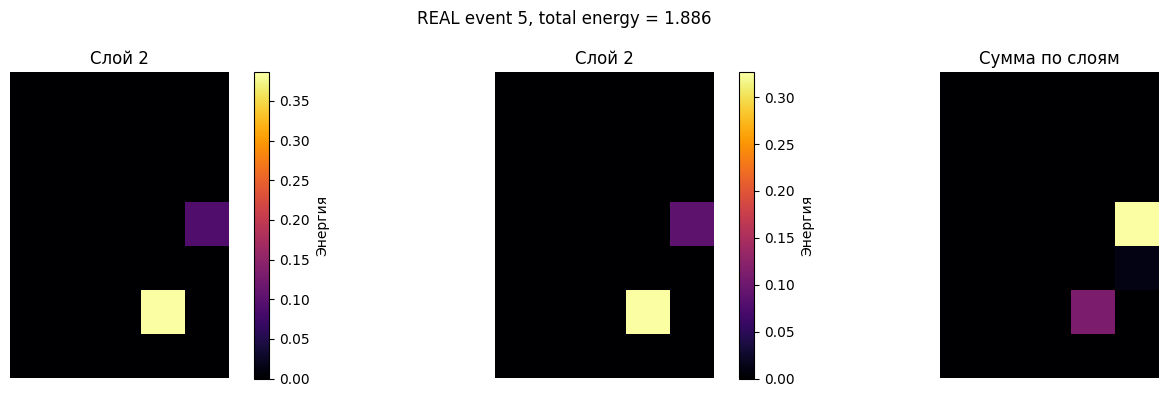

In [ ]:
# Сравнение данных с лог преобразованием
show_one_energy_event_row(train_dataset, idx=5, layer=1)

In [ ]:
from pipeline.metrics import CriticValuesDistributionMetric, Metric, MetricsSequence, PHYS_STATISTICS, PhysicsDataStatistics
from pipeline.custom_metrics import *


def form_metric() -> Metric:
    return MetricsSequence(
        CriticValuesDistributionMetric(values_cnt=5000),
        PhysicsDataStatistics(
            *[statistic_cls() for statistic_cls in PHYS_STATISTICS],
            create_prd_energy_embed(),
            create_conditional_prd_energy_embed(),
            create_prd_physics_statistics(),
            create_conditional_prd_physics_statistics(),
        ),
    )

✅ Загружен обученный эмбеддер


In [ ]:
from pipeline.predicates import TrainPredicate, IgnoreFirstNEpochsPredicate, EachNthEpochPredicate


def form_metric_predicate() -> TrainPredicate:
    # начиная с 10-й эпохи, метрики будут вычисляться на каждой 5-ой
    return IgnoreFirstNEpochsPredicate(10) & EachNthEpochPredicate(5)

In [ ]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: elleth956428 (elleth956428-hse-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
import contextlib

from pipeline.wandb_logger import WandbCM


def init_logger(model_name: str):
    project_name = 'GAN_DEMO'
    @contextlib.contextmanager
    def logger_cm():
        try:
            with WandbCM(project_name=project_name, experiment_id=model_name) as wandb_logger:
                yield wandb_logger
        finally:
            pass
    return logger_cm

In [ ]:
from pipeline.storage import ExperimentsStorage


def init_storage() -> ExperimentsStorage:

    experiments_dir = './experiments'
    checkpoint_filename = './training_checkpoint'
    model_state_filename = './model_state'

    return ExperimentsStorage(experiments_dir=experiments_dir, checkpoint_filename=checkpoint_filename,
                              model_state_filename=model_state_filename)

In [ ]:
experiments_storage = init_storage()

In [ ]:
from visualization_aux.visualize_physics import get_test_data
from pipeline.config import GlobalConfig, PathsConfig
from pipeline.device import get_local_device
correct_path = '/content/drive/MyDrive/GAN_project/data'

global_config = GlobalConfig(
    paths=PathsConfig(data_dir_path=correct_path, experiments='./experiments'),
    logger=None
)

visualization_data = get_test_data(global_config)
visualization_data = (visualization_data[0], visualization_data[1][:5].to(get_local_device()), visualization_data[2][:5].to(get_local_device()))

In [ ]:
from visualization_aux.common import gen_several_images

Обучение с новой функцией визуализации и сохранением сгенерированных данных

In [ ]:
import importlib
import pipeline.train as train_module

importlib.reload(train_module)

from pipeline.train import GanTrainer, Stepper, WganEpochTrainer

In [ ]:
from typing import Generator, Tuple

from pipeline.discriminators import CaloganPhysicsDiscriminator
from pipeline.gan import GAN
from pipeline.generators import CaloganPhysicsGenerator
from pipeline.normalization import apply_normalization, SpectralNormalizer
from pipeline.train import GanTrainer, Stepper, WganEpochTrainer


def form_gan_trainer(model_name: str, n_epochs: int) -> Generator[Tuple[int, GAN], None, GAN]:
    logger_cm_fn = init_logger(model_name)
    metric = form_metric()
    metric_predicate = form_metric_predicate()

    train_dataset = form_dataset(True)
    val_dataset = form_dataset(False)

    noise_dimension = 50

    def uniform_noise_generator(n: int) -> torch.Tensor:
        return 2*torch.rand(size=(n, noise_dimension)) - 1

    generator = CaloganPhysicsGenerator(noise_dim=noise_dimension)
    discriminator = CaloganPhysicsDiscriminator()
    discriminator = apply_normalization(discriminator, SpectralNormalizer)

    gan_model = GAN(generator, discriminator, uniform_noise_generator)

    generator_stepper = Stepper(
        optimizer=torch.optim.RMSprop(generator.parameters(), lr=1e-4)
    )

    discriminator_stepper = Stepper(
        optimizer=torch.optim.RMSprop(discriminator.parameters(), lr=1e-4)
    )

    epoch_trainer = WganEpochTrainer(n_critic=5, batch_size=100)

    model_dir = experiments_storage.get_model_dir(model_name)
    trainer = GanTrainer(model_dir=model_dir, use_saved_checkpoint=True, save_checkpoint_once_in_epoch=10)
    train_gan_generator = trainer.train(gan_model=gan_model,
                                        train_dataset=train_dataset, val_dataset=val_dataset,
                                        generator_stepper=generator_stepper,
                                        critic_stepper=discriminator_stepper,
                                        epoch_trainer=epoch_trainer,
                                        n_epochs=n_epochs,
                                        metric=metric,
                                        metric_predicate=metric_predicate,
                                        logger_cm_fn=logger_cm_fn)

    return train_gan_generator

In [ ]:
from visualization_aux.common import visualize_last_event

In [ ]:
# Переопределяем функцию log_metric
import pipeline.metrics_logging as ml
from pipeline.metrics import MetricsSequence
def custom_log_metric(metric, results, logger, period='epoch', period_index=0, quantile_removed=None):


    if logger is None:
        return


    if isinstance(metric, MetricsSequence):

        if isinstance(results, dict):
            data = results


        elif isinstance(results, (tuple, list)):
            data = {}
            for i, value in enumerate(results):
                data[f"metric_{i}"] = value

        else:
            data = {"metric": results}

        logger.log_metrics(
            data=data,
            period=period,
            period_index=period_index,
            commit=False
        )
        logger.commit(period=period)
        return


    if hasattr(metric, 'log'):
        metric.log(results, logger, period, period_index, quantile_removed)
        return


    if isinstance(results, dict):
        data = results
    elif isinstance(results, (tuple, list)):
        data = {f"metric_{i}": value for i, value in enumerate(results)}
    else:
        data = {"metric": results}

    logger.log_metrics(
        data=data,
        period=period,
        period_index=period_index,
        commit=False
    )
    logger.commit(period=period)


ml.log_metric = custom_log_metric

In [ ]:
# Если требуется вывод PRD
import importlib

import pipeline.metrics_logging as ml
import pipeline.train as train_module

importlib.reload(ml)

train_module.log_metric = ml.log_metric

In [ ]:
gan_trainer = form_gan_trainer(model_name='physics demo', n_epochs=30)

In [ ]:
import importlib
import pipeline.physical_metrics.calogan_metrics as calogan_metrics
importlib.reload(calogan_metrics)

<module 'pipeline.physical_metrics.calogan_metrics' from '/content/drive/MyDrive/GAN_project/pipeline/physical_metrics/calogan_metrics.py'>

Checkpoint was loaded. Current epoch: 30


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: elleth956428 (elleth956428-hse-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


  1%|          | 1/101 [00:01<02:53,  1.74s/it]


=== ENERGY DEBUG ===
batch_index: 0
real energy min/mean/max: 0.012141920626163483 2.0477752685546875 5.154238224029541
fake energy min/mean/max: 0.0 2.174055814743042 6.782131195068359
real abs mean: 0.00835826713591814
fake abs mean: 0.008873697370290756
real nonzero ratio: 0.01677550934255123
fake nonzero ratio: 0.022163264453411102

=== ENERGY LOSS DEBUG ===
adv_gen_loss: 0.0003647591220214963
energy_loss: 1.555050015449524
lambda_energy: 0.002
lambda_energy * energy_loss: 0.003110100282356143
sparsity_loss: 0.008873697370290756
lambda_sparsity: 0.005
lambda_sparsity * sparsity_loss: 4.436848757904954e-05
layer_frac_loss: 0.0567249059677124
lambda_layer_fraction: 0.1
lambda_layer_fraction * layer_frac_loss: 0.005672490689903498
quantile_loss: 0.39095526933670044
lambda_quantile: 0.005
lambda_quantile * quantile_loss: 0.0019547762349247932
gen_loss total: 0.01114649511873722


 52%|█████▏    | 53/101 [00:05<00:03, 12.84it/s]

...

100%|██████████| 101/101 [00:09<00:00, 10.27it/s]


=== ENERGY DEBUG ===
batch_index: 100
real energy min/mean/max: 0.0033022842835634947 2.1507418155670166 4.56618595123291
fake energy min/mean/max: 0.015520530752837658 2.2373907566070557 5.538684368133545
real abs mean: 0.00877853762358427
fake abs mean: 0.009132208302617073
real nonzero ratio: 0.01884753815829754
fake nonzero ratio: 0.022208882495760918

=== ENERGY LOSS DEBUG ===
adv_gen_loss: 0.002271875273436308
energy_loss: 1.5303690433502197
lambda_energy: 0.002
lambda_energy * energy_loss: 0.0030607383232563734
sparsity_loss: 0.009132208302617073
lambda_sparsity: 0.005
lambda_sparsity * sparsity_loss: 4.5661039621336386e-05
layer_frac_loss: 0.04712686687707901
lambda_layer_fraction: 0.1
lambda_layer_fraction * layer_frac_loss: 0.004712686873972416
quantile_loss: 0.11813871562480927
lambda_quantile: 0.005
lambda_quantile * quantile_loss: 0.000590693554840982
gen_loss total: 0.010681654326617718
  Средний loss критика: -0.0017
  Средний loss генератора: 0.0119
  Средний adv loss 


9it [01:32, 10.28s/it]
9it [00:53,  5.96s/it]


epochs done: 30


/content/drive/MyDrive/GAN_project/visualization_aux/common.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


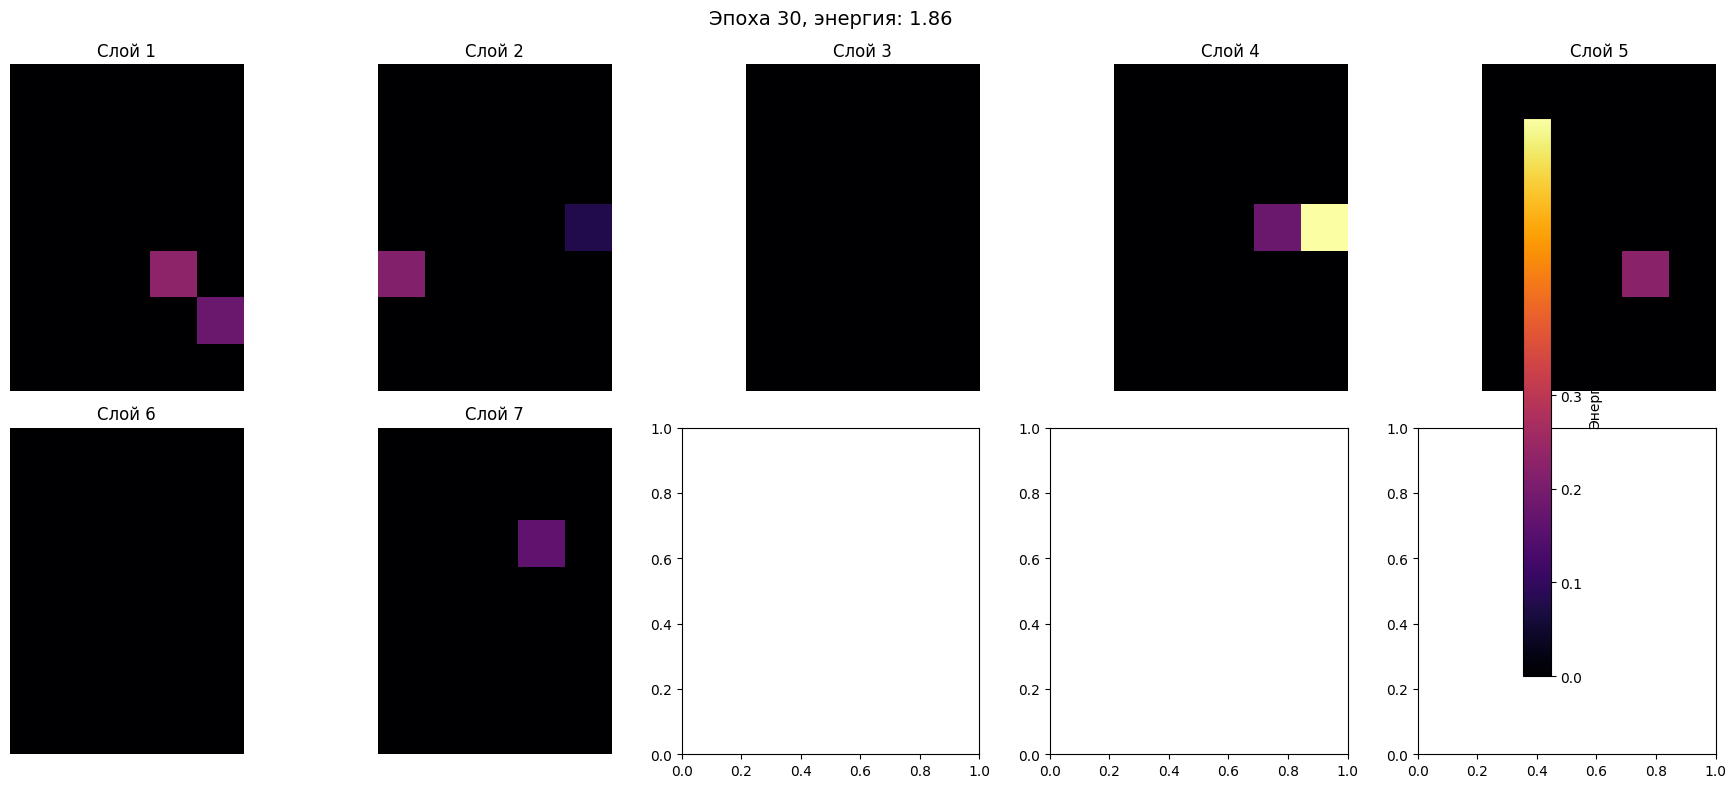

Energy PRD PR-AUC,▁
PhysStats PRD PR-AUC,▁
bin #0: Energy embed. Average PRD-AUC,▁
bin #0: PhysStats Average PRD-AUC,▁
bin #1: Energy embed. Average PRD-AUC,▁
bin #1: PhysStats Average PRD-AUC,▁
bin #2: Energy embed. Average PRD-AUC,▁
bin #2: PhysStats Average PRD-AUC,▁
bin #3: Energy embed. Average PRD-AUC,▁
bin #3: PhysStats Average PRD-AUC,▁
+28,...


In [ ]:
for epoch, gan in gan_trainer:
    print(f'epochs done: {epoch-1}')

    # Берем последнюю точку и импульс из батча
    last_point = visualization_data[1][-1:]   # последняя точка (1, 2)
    last_momentum = visualization_data[2][-1:] # последний импульс (1, 3)

    visualize_last_event(
        gan,
        last_point,
        last_momentum,
        epoch=epoch-1,
        figsize=(18, 8)
    )

Метрики по энергии и распределение

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pipeline.data import collate_fn, move_batch_to
from pipeline.device import get_local_device

def get_real_fake_samples(gan, dataset, n_samples=2000):
    gan.eval()

    n_samples = min(n_samples, len(dataset))
    batch = [dataset[i] for i in range(n_samples)]

    real_x, real_y = collate_fn(batch)
    real_x = real_x.to(get_local_device())
    real_y = move_batch_to(real_y, get_local_device())

    real_y = (real_y[0][:, :2], real_y[1])

    with torch.no_grad():
        z = gan.gen_noise(len(real_x)).to(get_local_device())
        fake_x = gan.generator(z, real_y)

    if getattr(dataset, "inverse_transform", None) is not None:
        real_x = dataset.inverse_transform(real_x)
        fake_x = dataset.inverse_transform(fake_x)

    return real_x.detach().cpu().numpy(), fake_x.detach().cpu().numpy()


def layer_energy(x):
    return x.sum(axis=(2, 3))


def layer_energy_fraction(x, eps=1e-12):
    e_layer = layer_energy(x)
    e_total = e_layer.sum(axis=1, keepdims=True)
    return e_layer / (e_total + eps)


def total_energy(x):
    return x.sum(axis=(1, 2, 3))


real, fake = get_real_fake_samples(gan, train_dataset, n_samples=2000)

real_layer = layer_energy(real)
fake_layer = layer_energy(fake)

real_frac = layer_energy_fraction(real)
fake_frac = layer_energy_fraction(fake)

real_total = total_energy(real)
fake_total = total_energy(fake)

Средняя доля энергии по слоям REAL: [0.5314569  0.25398013 0.11036974 0.05854975 0.02702543 0.0120274
 0.0065906 ]
Средняя доля энергии по слоям FAKE: [0.59533906 0.2560085  0.07630827 0.04311608 0.01437002 0.00316356
 0.00819455]
MAE по layer energy fraction: 0.019789841


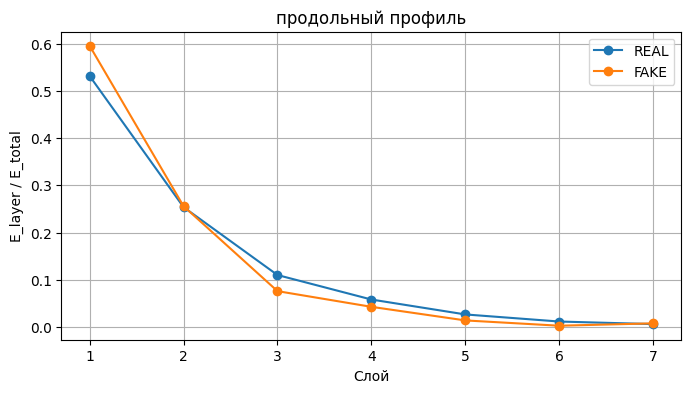

In [ ]:
real_frac_mean = real_frac.mean(axis=0)
fake_frac_mean = fake_frac.mean(axis=0)

mae_layer_fraction = np.mean(np.abs(real_frac_mean - fake_frac_mean))

print("Средняя доля энергии по слоям REAL:", real_frac_mean)
print("Средняя доля энергии по слоям FAKE:", fake_frac_mean)
print("MAE по layer energy fraction:", mae_layer_fraction)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 8), real_frac_mean, marker='o', label='REAL')
plt.plot(np.arange(1, 8), fake_frac_mean, marker='o', label='FAKE')
plt.xlabel('Слой')
plt.ylabel('E_layer / E_total')
plt.title('продольный профиль')
plt.legend()
plt.grid(True)
plt.show()

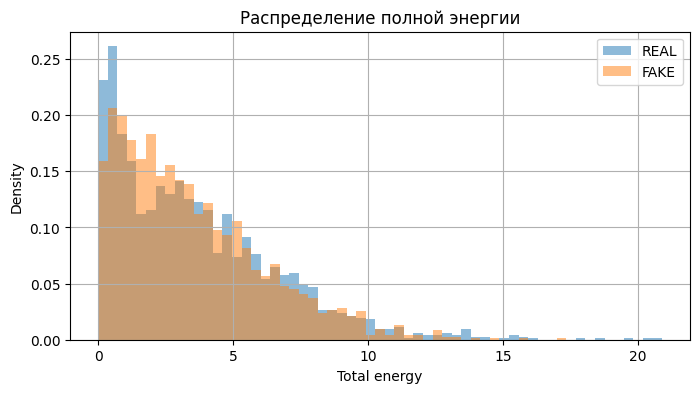

REAL total energy: min/max = 0.0011511574 20.885075
FAKE total energy: min/max = 0.0 17.284157


In [ ]:
bins = np.linspace(
    min(real_total.min(), fake_total.min()),
    max(real_total.max(), fake_total.max()),
    60
)

plt.figure(figsize=(8, 4))
plt.hist(real_total, bins=bins, alpha=0.5, density=True, label='REAL')
plt.hist(fake_total, bins=bins, alpha=0.5, density=True, label='FAKE')
plt.xlabel('Total energy')
plt.ylabel('Density')
plt.title('Распределение полной энергии')
plt.legend()
plt.grid(True)
plt.show()

print("REAL total energy: min/max =", real_total.min(), real_total.max())
print("FAKE total energy: min/max =", fake_total.min(), fake_total.max())

In [ ]:
for name, arr in [('REAL', real_total), ('FAKE', fake_total)]:
    q = np.quantile(arr, [0.01, 0.05, 0.5, 0.95, 0.99])
    print(
        name,
        "q01/q05/median/q95/q99 =",
        q
    )

REAL q01/q05/median/q95/q99 = [ 0.05344732  0.22741059  3.03215396  9.32486196 13.66296205]
FAKE q01/q05/median/q95/q99 = [ 0.05525863  0.32526473  2.87076521  8.7008687  11.27716888]


Анализ распределения энергии по слоям и без

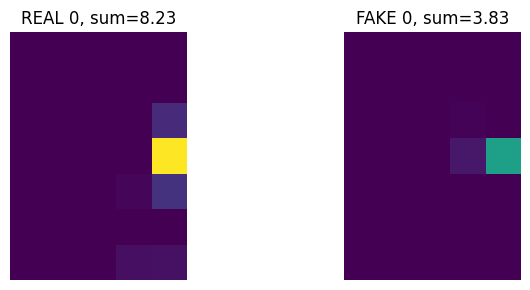

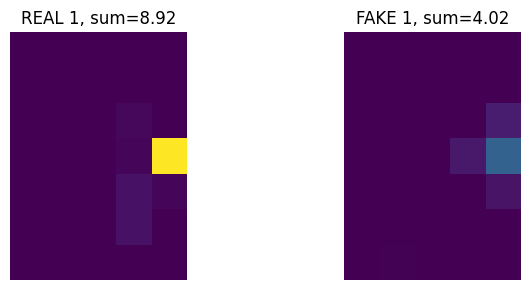

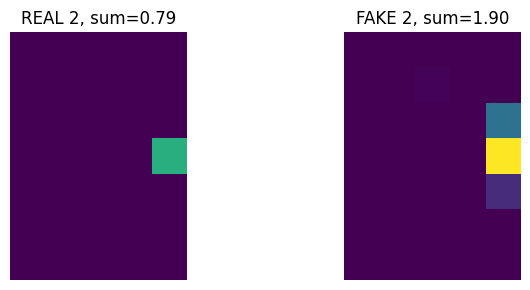

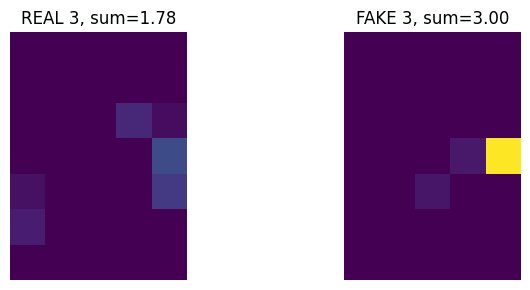

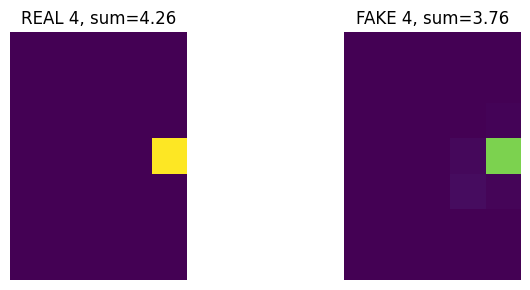

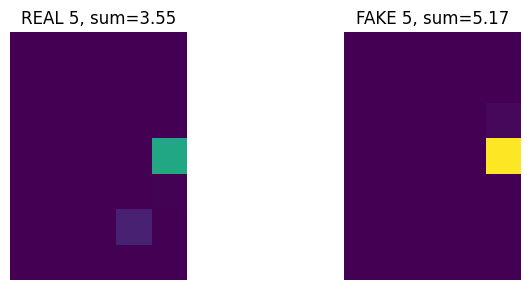

In [ ]:
import torch
import matplotlib.pyplot as plt
from pipeline.data import collate_fn, move_batch_to
from pipeline.device import get_local_device

gan.eval()


batch = [train_dataset[i] for i in range(6)]
real_x, real_y = collate_fn(batch)
real_x = real_x.to(get_local_device())
real_y = move_batch_to(real_y, get_local_device())
real_y = (real_y[0][:, :2], real_y[1])

with torch.no_grad():
    z = gan.gen_noise(len(real_x)).to(get_local_device())
    fake_x = gan.generator(z, real_y)


if getattr(train_dataset, "inverse_transform", None) is not None:
    real_plot = train_dataset.inverse_transform(real_x).detach().cpu()
    fake_plot = train_dataset.inverse_transform(fake_x).detach().cpu()
else:
    real_plot = real_x.detach().cpu()
    fake_plot = fake_x.detach().cpu()


real_2d = real_plot.sum(dim=1)
fake_2d = fake_plot.sum(dim=1)

for i in range(6):
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    vmax = max(real_2d[i].max().item(), fake_2d[i].max().item())

    axes[0].imshow(real_2d[i], vmin=0, vmax=vmax)
    axes[0].set_title(f"REAL {i}, sum={real_2d[i].sum().item():.2f}")
    axes[0].axis("off")

    axes[1].imshow(fake_2d[i], vmin=0, vmax=vmax)
    axes[1].set_title(f"FAKE {i}, sum={fake_2d[i].sum().item():.2f}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

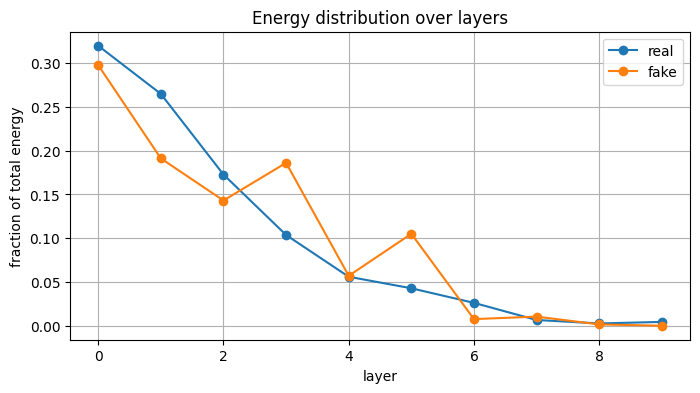

real layer fractions: [0.31980795 0.26480967 0.17276278 0.10371845 0.05601867 0.04287106
 0.02620752 0.00664173 0.00270474 0.00445744]
fake layer fractions: [2.9768917e-01 1.9115193e-01 1.4308220e-01 1.8606582e-01 5.7116166e-02
 1.0505647e-01 7.6577640e-03 1.0507326e-02 1.5660673e-03 1.0708002e-04]


In [ ]:
import torch
import matplotlib.pyplot as plt

from pipeline.data import collate_fn, move_batch_to
from pipeline.device import get_local_device

gan.eval()

batch = [train_dataset[i] for i in range(200)]
real_x, real_y = collate_fn(batch)
real_x = real_x.to(get_local_device())
real_y = move_batch_to(real_y, get_local_device())

with torch.no_grad():
    z = gan.gen_noise(len(real_x)).to(get_local_device())
    fake_x = gan.generator(z, real_y)

if getattr(train_dataset, "inverse_transform", None) is not None:
    real_raw = train_dataset.inverse_transform(real_x).detach().cpu()
    fake_raw = train_dataset.inverse_transform(fake_x).detach().cpu()
else:
    real_raw = real_x.detach().cpu()
    fake_raw = fake_x.detach().cpu()

real_layer_energy = real_raw.sum(dim=(0, 2, 3))
fake_layer_energy = fake_raw.sum(dim=(0, 2, 3))

real_layer_energy = real_layer_energy / real_layer_energy.sum()
fake_layer_energy = fake_layer_energy / fake_layer_energy.sum()

plt.figure(figsize=(8, 4))
plt.plot(real_layer_energy.numpy(), marker="o", label="real")
plt.plot(fake_layer_energy.numpy(), marker="o", label="fake")
plt.xlabel("layer")
plt.ylabel("fraction of total energy")
plt.title("Energy distribution over layers")
plt.legend()
plt.grid(True)
plt.show()

print("real layer fractions:", real_layer_energy.numpy())
print("fake layer fractions:", fake_layer_energy.numpy())

In [ ]:
import torch
import matplotlib.pyplot as plt

from pipeline.data import collate_fn, move_batch_to
from pipeline.device import get_local_device

gan.eval()

batch = [train_dataset[i] for i in range(8)]
real_x, real_y = collate_fn(batch)
real_x = real_x.to(get_local_device())
real_y = move_batch_to(real_y, get_local_device())

with torch.no_grad():
    z1 = gan.gen_noise(len(real_x)).to(get_local_device())
    z2 = gan.gen_noise(len(real_x)).to(get_local_device())

    fake1 = gan.generator(z1, real_y)
    fake2 = gan.generator(z2, real_y)

if getattr(train_dataset, "inverse_transform", None) is not None:
    fake1 = train_dataset.inverse_transform(fake1).detach().cpu()
    fake2 = train_dataset.inverse_transform(fake2).detach().cpu()
else:
    fake1 = fake1.detach().cpu()
    fake2 = fake2.detach().cpu()

fake1_2d = fake1.sum(dim=1)
fake2_2d = fake2.sum(dim=1)

for i in range(8):
    diff = torch.mean(torch.abs(fake1_2d[i] - fake2_2d[i])).item()
    print(f"event {i}: mean abs difference between two noises = {diff:.6f}")

event 0: mean abs difference between two noises = 0.007359
event 1: mean abs difference between two noises = 0.016237
event 2: mean abs difference between two noises = 0.011522
event 3: mean abs difference between two noises = 0.019819
event 4: mean abs difference between two noises = 0.008465
event 5: mean abs difference between two noises = 0.015468
event 6: mean abs difference between two noises = 0.009486
event 7: mean abs difference between two noises = 0.022927


Обучение со старой функцией визуализации

In [ ]:
for epoch, gan in gan_trainer:
    print(f'epochs done: {epoch-1}')
    gen_several_images(gan, len(visualization_data[0]), y=visualization_data[1:], figsize=(20, 11), imshow_fn=energy_imshow)

In [ ]:
# принудительная перезагрузка всех модулей
import sys
import importlib

modules_to_reload = [
    # 'pipeline.discriminators',
    # 'pipeline.generators',
    'pipeline.gan',
    # 'visualization_aux.common'
    # 'visualization_aux.visualize_physics'
    'pipeline.physical_metrics',
    'pipeline.physical_metrics.calogan_metrics',
    'pipeline.physical_metrics.calogan_prd',
    'pipeline.physical_metrics.prd_score',
    'pipeline.metrics'
    'pipeline.train'
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])
        print(f"Перезагружен: {module_name}")

print("Все модули перезагружены")

Перезагружен: pipeline.gan
Перезагружен: pipeline.physical_metrics
Перезагружен: pipeline.physical_metrics.calogan_metrics
✅ Загружен обученный эмбеддер
Перезагружен: pipeline.physical_metrics.calogan_prd
Перезагружен: pipeline.physical_metrics.prd_score
Все модули перезагружены!


In [ ]:
import importlib
import visualization_aux.common as vis_common

importlib.reload(vis_common)

from visualization_aux.common import visualize_last_event

In [ ]:
from pipeline.metrics import *
from pipeline.custom_metrics import *
from pipeline.physical_metrics import *

Обучение эмбеддера


In [ ]:
import numpy as np
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from pipeline.physical_metrics.calogan_prd import Regressor

Загрузка данных...
EnergyDeposit after transpose: (20067, 7, 7, 5)
EnergyDeposit shape: (20067, 7, 7, 5)
ParticlePoint shape: (20067, 2)
ParticleMomentum shape: (20067, 3)
TotalEnergy shape: (20067,)
LayerFrac shape: (20067, 7)


Epoch 1: train_loss=1.356723, val_loss=1.289971, lr=0.001000


Epoch 2: train_loss=1.286909, val_loss=1.283118, lr=0.001000


Epoch 3: train_loss=1.270620, val_loss=1.279539, lr=0.001000


Epoch 4: train_loss=1.264255, val_loss=1.273790, lr=0.001000


...

Epoch 18: train_loss=1.186697, val_loss=1.278191, lr=0.000500


Epoch 19: train_loss=1.182338, val_loss=1.286520, lr=0.000250


Epoch 20: train_loss=1.164192, val_loss=1.281835, lr=0.000250


Epoch 21: train_loss=1.161004, val_loss=1.291621, lr=0.000250


Epoch 22: train_loss=1.154165, val_loss=1.287731, lr=0.000250
Early stopping at epoch 22

✅ Эмбеддер сохранен с параметрами нормализации


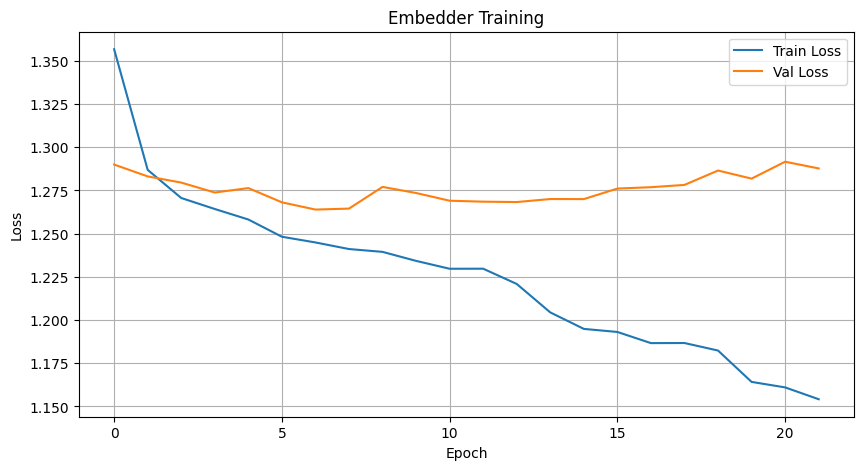

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm


class Regressor(nn.Module):
    def __init__(self):
        super(Regressor, self).__init__()

        self.batchnorm0 = nn.BatchNorm2d(7)

        self.conv1 = nn.Conv2d(7, 16, 3, stride=2, padding=1)
        self.batchnorm1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.batchnorm2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.batchnorm3 = nn.BatchNorm2d(64)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.1)

        self.fc1 = nn.Linear(64, 256)
        self.batchnorm4 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)

        self.fc4 = nn.Linear(64, 5)   # x, y, px, py, pz
        self.fc5 = nn.Linear(64, 1)   # total energy
        self.fc6 = nn.Linear(64, 7)   # доля энергии по 7 слоям

    def _encode_base(self, x):
        x = self.batchnorm0(x)
        x = self.batchnorm1(F.relu(self.conv1(x)))
        x = self.batchnorm2(F.relu(self.conv2(x)))
        x = self.batchnorm3(F.relu(self.conv3(x)))

        x = self.adaptive_pool(x)
        x = x.view(len(x), -1)

        x = self.dropout(x)
        x = self.batchnorm4(F.relu(self.fc1(x)))
        x = F.leaky_relu(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        return x

    def forward(self, x):
        encoding = self._encode_base(x)

        pred_condition = self.fc4(encoding)
        pred_energy = self.fc5(encoding)
        pred_layer_frac = F.softmax(self.fc6(encoding), dim=1)

        return pred_condition, pred_energy, pred_layer_frac

    def get_encoding(self, x):
        return self._encode_base(x)


class EmbedderDataset(Dataset):
    def __init__(self, EnergyDeposit, ParticlePoint, ParticleMomentum, TotalEnergy, LayerFrac):
        self.EnergyDeposit = torch.FloatTensor(EnergyDeposit)
        self.ParticlePoint = torch.FloatTensor(ParticlePoint)
        self.ParticleMomentum = torch.FloatTensor(ParticleMomentum)
        self.TotalEnergy = torch.FloatTensor(TotalEnergy).reshape(-1, 1)
        self.LayerFrac = torch.FloatTensor(LayerFrac)

    def __len__(self):
        return len(self.EnergyDeposit)

    def __getitem__(self, idx):
        return (
            self.EnergyDeposit[idx],
            (
                self.ParticlePoint[idx],
                self.ParticleMomentum[idx],
                self.TotalEnergy[idx],
                self.LayerFrac[idx],
            )
        )


def normalize_data(data, mean=None, std=None):
    if mean is None:
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0)
    data_norm = (data - mean) / (std + 1e-8)
    return data_norm, mean, std


def calc_layer_fraction(EnergyDeposit, eps=1e-12):
    # EnergyDeposit: (N, 7, 7, 5)
    layer_energy = EnergyDeposit.sum(axis=(2, 3))  # (N, 7)
    total_energy = layer_energy.sum(axis=1, keepdims=True)
    layer_frac = layer_energy / (total_energy + eps)
    return layer_frac


print("Загрузка данных...")
data = np.load('/content/drive/MyDrive/GAN_project/data/fhcal_data3.npz')

EnergyDeposit = data['EnergyDeposit']

# Используем только x, y, без z
ParticlePoint = data['ParticlePoint'][:, :2]
ParticleMomentum = data['ParticleMomentum']

if EnergyDeposit.shape[1:] == (7, 5, 7):
    EnergyDeposit = np.transpose(EnergyDeposit, (0, 3, 1, 2))
    print(f"EnergyDeposit after transpose: {EnergyDeposit.shape}")

if 'TotalEnergySci' in data.files:
    TotalEnergy = data['TotalEnergySci']
else:
    TotalEnergy = np.sum(EnergyDeposit, axis=(1, 2, 3))

LayerFrac = calc_layer_fraction(EnergyDeposit)

print(f"EnergyDeposit shape: {EnergyDeposit.shape}")
print(f"ParticlePoint shape: {ParticlePoint.shape}")
print(f"ParticleMomentum shape: {ParticleMomentum.shape}")
print(f"TotalEnergy shape: {TotalEnergy.shape}")
print(f"LayerFrac shape: {LayerFrac.shape}")

ParticlePoint_norm, point_mean, point_std = normalize_data(ParticlePoint)
ParticleMomentum_norm, mom_mean, mom_std = normalize_data(ParticleMomentum)
TotalEnergy_norm, energy_mean, energy_std = normalize_data(TotalEnergy.reshape(-1, 1))

X_train, X_val, yp_train, yp_val, ym_train, ym_val, ye_train, ye_val, yf_train, yf_val = train_test_split(
    EnergyDeposit,
    ParticlePoint_norm,
    ParticleMomentum_norm,
    TotalEnergy_norm,
    LayerFrac,
    test_size=0.2,
    random_state=42
)

train_dataset = EmbedderDataset(X_train, yp_train, ym_train, ye_train, yf_train)
val_dataset = EmbedderDataset(X_val, yp_val, ym_val, ye_val, yf_val)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embedder = Regressor().to(device)

optimizer = torch.optim.Adam(embedder.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

criterion = nn.MSELoss()

epochs = 100
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 15

lambda_energy_embedder = 0.1
lambda_layer_frac_embedder = 0.5

for epoch in range(epochs):
    embedder.train()
    total_loss = 0

    for x, (point, momentum, total_energy, layer_frac) in tqdm(
        train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False
    ):
        x = x.to(device)
        point = point.to(device)
        momentum = momentum.to(device)
        total_energy = total_energy.to(device)
        layer_frac = layer_frac.to(device)

        pred_all, pred_energy, pred_layer_frac = embedder(x)

        pred_point = pred_all[:, :2]
        pred_momentum = pred_all[:, 2:5]

        loss_point = criterion(pred_point, point)
        loss_momentum = criterion(pred_momentum, momentum)
        loss_energy = criterion(pred_energy, total_energy)
        loss_layer_frac = criterion(pred_layer_frac, layer_frac)

        loss = (
            loss_point
            + loss_momentum
            + lambda_energy_embedder * loss_energy
            + lambda_layer_frac_embedder * loss_layer_frac
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    embedder.eval()
    val_loss = 0

    with torch.no_grad():
        for x, (point, momentum, total_energy, layer_frac) in val_loader:
            x = x.to(device)
            point = point.to(device)
            momentum = momentum.to(device)
            total_energy = total_energy.to(device)
            layer_frac = layer_frac.to(device)

            pred_all, pred_energy, pred_layer_frac = embedder(x)

            pred_point = pred_all[:, :2]
            pred_momentum = pred_all[:, 2:5]

            loss_point = criterion(pred_point, point)
            loss_momentum = criterion(pred_momentum, momentum)
            loss_energy = criterion(pred_energy, total_energy)
            loss_layer_frac = criterion(pred_layer_frac, layer_frac)

            loss = (
                loss_point
                + loss_momentum
                + lambda_energy_embedder * loss_energy
                + lambda_layer_frac_embedder * loss_layer_frac
            )

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(embedder.state_dict(), '/content/embedder_best.pt')
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch+1}: "
        f"train_loss={avg_train_loss:.6f}, "
        f"val_loss={avg_val_loss:.6f}, "
        f"lr={optimizer.param_groups[0]['lr']:.6f}"
    )

    if patience_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

embedder.load_state_dict(torch.load('/content/embedder_best.pt'))

save_dict = {
    'model_state': embedder.state_dict(),
    'point_mean': point_mean,
    'point_std': point_std,
    'mom_mean': mom_mean,
    'mom_std': mom_std,
    'energy_mean': energy_mean,
    'energy_std': energy_std,
}

torch.save(
    save_dict,
    '/content/drive/MyDrive/GAN_project/pipeline/physical_metrics/embedder_state_7x5_xy_energy_frac.pt'
)

print("\n✅ Эмбеддер сохранен с параметрами нормализации")

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Embedder Training')
plt.legend()
plt.grid(True)
plt.show()